In [54]:
import cv2 as cv
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib.pyplot as plt

In [66]:
def build_gaussian_pyramid(img, num_levels):
    """Copied from the class"""
    lower = img.copy()
    gaussian_pyr = [lower]
    for i in range(num_levels):
        lower = cv.pyrDown(lower)
        gaussian_pyr.append(np.float32(lower))
    return gaussian_pyr


def resize_image(image, scale):
    width = int(image.shape[1] * scale)
    height = int(image.shape[0] * scale)
    return width, height, cv.resize(image, (width, height))


def match_pattern(image, pattern, threshold, method=cv.TM_CCOEFF_NORMED, max_post_process=False):
    scale = np.linspace(0.21,0.26,40)

    found = []
    for scale in scale:
        width, height, templ = resize_image(pattern, scale)

        try:
            response = cv.matchTemplate(image, templ, method)
        except cv.error as err:
            print(f'Error al procesar la imagen con el template de tamaño {width}x{height} -- {err}')
            continue

        if max_post_process:
            aux_response = response.copy()

            _, score, _, (x, y) = cv.minMaxLoc(aux_response)
            while score < threshold:                
                found.append([x, y, x + width, y + height, score])

                # Set the found pattern to 0 to remove it from the response
                y1, y2 = max(0, y - height // 2), min(aux_response.shape[0], y + height)
                x1, x2 = max(0, x - width // 2), min(aux_response.shape[1], x + width)
                aux_response[y1:y2, x1:x2] = 0

                _, score, _, (x, y) = cv.minMaxLoc(aux_response)
        else:
            locations = np.where(response >= threshold)
            for x, y in zip(*locations[::-1]):
                found.append([x, y, x + width, y + height, float(response[y, x])])

        print(
        f"scale={scale:.2f}",
        f"matches={(response >= threshold).sum()}"
        )

    return found

def iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    return inter / (area_a + area_b - inter + 1e-6)

def filter_by_nms(boxes, overlap):
    boxes = sorted(boxes, key=lambda b: b[4], reverse=True)
    keep = []
    while boxes:
        best = boxes.pop(0)
        keep.append(best)
        boxes = [b for b in boxes if iou(best, b) < overlap]
    return keep


def detect_multiple(gray, pattern, threshold, overlap):
    found = match_pattern(gray, pattern, threshold)

    pattern_inv = 255 - pattern
    inv_found = match_pattern(gray, pattern_inv, threshold)

    return filter_by_nms(found + inv_found, overlap)


def detect_multiple_pyramid(gray, pyramid_pattern, threshold, overlap):
    found = []
    for level in range(len(pyramid_pattern)):
        pattern = pyramid_pattern[level]
        detected = detect_multiple(gray, pattern, threshold, overlap)

        found.extend(detected)

    return filter_by_nms(found, overlap)


def draw_detections(image, detections, title=''):
    plt.figure(figsize=(10, 7))

    for x1, y1, x2, y2, _ in detections:
        cv.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()


In [56]:
_, template_bin = cv.threshold(
    template,
    180,
    255,
    cv.THRESH_BINARY_INV
)

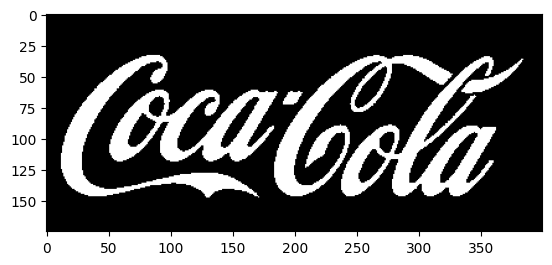

In [57]:
plt.imshow(template_bin, cmap='gray')

In [58]:
image_bin = cv.adaptiveThreshold(
    multi_gray,
    255,
    cv.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv.THRESH_BINARY,
    11,
    2
)

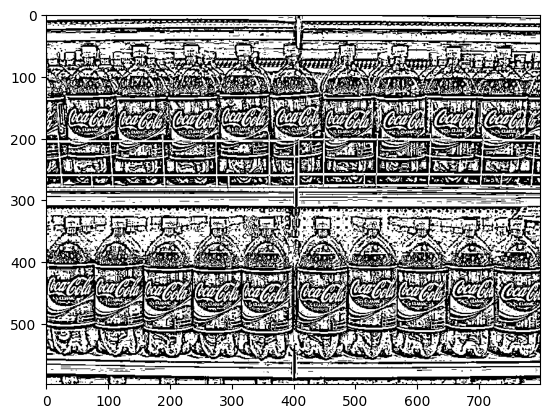

In [59]:
plt.imshow(image_bin, cmap='gray')

scale=0.21 matches=0
scale=0.21 matches=0
scale=0.21 matches=0
scale=0.21 matches=0
scale=0.22 matches=0
scale=0.22 matches=0
scale=0.22 matches=0
scale=0.22 matches=0
scale=0.22 matches=1
scale=0.22 matches=1
scale=0.22 matches=4
scale=0.22 matches=6
scale=0.23 matches=7
scale=0.23 matches=7
scale=0.23 matches=9
scale=0.23 matches=19
scale=0.23 matches=22
scale=0.23 matches=22
scale=0.23 matches=21
scale=0.23 matches=20
scale=0.24 matches=20
scale=0.24 matches=20
scale=0.24 matches=13
scale=0.24 matches=13
scale=0.24 matches=13
scale=0.24 matches=13
scale=0.24 matches=9
scale=0.24 matches=9
scale=0.25 matches=5
scale=0.25 matches=5
scale=0.25 matches=1
scale=0.25 matches=1
scale=0.25 matches=0
scale=0.25 matches=0
scale=0.25 matches=0
scale=0.25 matches=0
scale=0.26 matches=0
scale=0.26 matches=0
scale=0.26 matches=0
scale=0.26 matches=0
scale=0.21 matches=0
scale=0.21 matches=0
scale=0.21 matches=0
scale=0.21 matches=0
scale=0.22 matches=0
scale=0.22 matches=0
scale=0.22 matches=0
sc

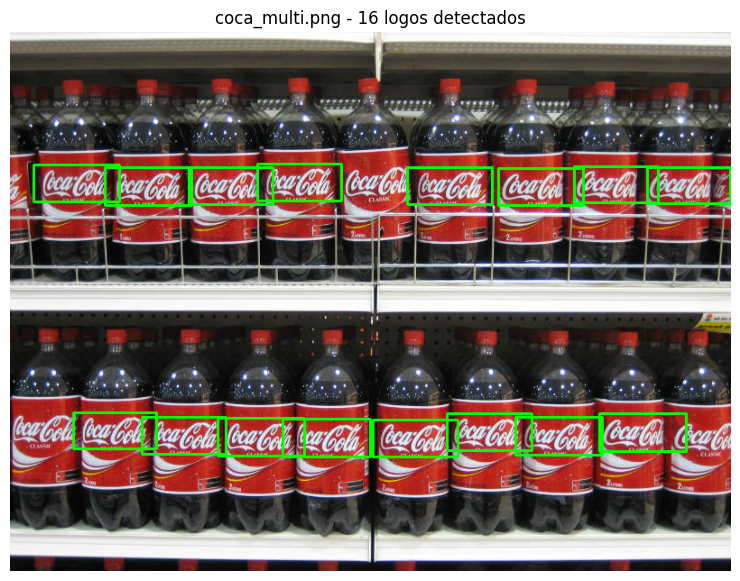

In [71]:
BASE_DIR = Path('.')
IMAGES_DIR = BASE_DIR / 'images'
TEMPLATE_PATH = BASE_DIR / 'template' / 'pattern.png'

multi_image_path = IMAGES_DIR / 'coca_multi.png'
multi_image = cv.imread(str(multi_image_path))
multi_gray = cv.cvtColor(multi_image, cv.COLOR_BGR2GRAY)

template = cv.imread(str(TEMPLATE_PATH), cv.IMREAD_GRAYSCALE)

threshold = 0.27
overlap = 0.3

## template_edges = cv.Canny(template, 50, 150)
## image_edges = cv.Canny(multi_gray, 50, 150)

## multi_detections = detect_multiple(multi_gray, template, threshold, overlap)
## multi_detections = detect_multiple(image_edges, template_edges, threshold, overlap)

multi_detections = detect_multiple(
    image_bin,
    template_bin,
    threshold,
    overlap
)


print(f'Detecciones en coca_multi.png: {len(multi_detections)}')
for idx, (_, _, _, _, score) in enumerate(sorted(multi_detections, key=lambda d: -d[4]), start=1):
    print(f'  {idx:2d}. confianza={score:.3f}')

draw_detections(
    multi_image,
    multi_detections,
    f'coca_multi.png - {len(multi_detections)} logos detectados',
)